# 08 — Backtesting (does the edge survive trading costs?)

**Inputs:** `predictions_classical.csv`, `predictions_dl.csv`, `btc_features.csv`
**Goal:** the real test. A 51% classifier *sounds* useless — but does it make money, and does any edge survive **transaction costs**? This is where most "predicts crypto!" projects quietly fall apart. I turn each model's signal into a strategy, charge realistic costs, and compare against the only baseline that matters: **buy and hold**.

In [1]:
import sys
from pathlib import Path
_p=Path.cwd()
while not (_p/"paths.py").exists() and _p!=_p.parent: _p=_p.parent
sys.path.insert(0,str(_p)); import paths
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid"); plt.rcParams["figure.dpi"]=110; plt.rcParams["savefig.dpi"]=150
STAGE="08_backtesting"; FIG=paths.figures_dir(STAGE); TAB=paths.tables_dir(STAGE); D=paths.PROCESSED_FILE.parent

clf=pd.read_csv(D/"predictions_classical.csv",parse_dates=["date"])
feat=pd.read_csv(D/"btc_features.csv",parse_dates=["date"])[["date","target_return"]]
bt=clf.merge(feat,on="date",how="left")

# deep model (LSTM or MLP) — name read from its metrics file
deep_name="Neural net"
dl_path=D/"predictions_dl.csv"
if dl_path.exists():
    dl=pd.read_csv(dl_path,parse_dates=["date"])
    bt=bt.merge(dl[["date","pred_deep"]],on="date",how="inner")
    dm=paths.figures_dir("07_deep_learning").parent/"tables"/"deep_metrics.csv"
    if dm.exists(): deep_name=pd.read_csv(dm)["model"].iloc[0]
print("Backtest window:",bt.date.min().date(),"->",bt.date.max().date(),"(",len(bt),"days ) | deep model:",deep_name)

Backtest window: 2024-12-15 -> 2026-06-15 ( 548 days ) | deep model: Neural net (MLP)


## Strategy mechanics
Predict up → hold BTC; predict down → flat (cash) or short. Return each day = position × realised next-day return. A **0.1%** cost is charged whenever the position changes — the killer for high-churn strategies. Buy & Hold just holds 1 the whole time.

In [2]:
COST=0.001; TRADING_DAYS=365
def run_strategy(position,rets,cost=COST):
    position=np.asarray(position,float); rets=np.asarray(rets,float)
    turn=np.abs(np.diff(np.concatenate([[0],position])))
    strat=position*rets-cost*turn; equity=np.exp(np.cumsum(strat))
    return strat,equity,int((turn>0).sum())
def metrics(strat,equity,trades):
    ann=strat.mean()*TRADING_DAYS; vol=strat.std()*np.sqrt(TRADING_DAYS)
    dd=(equity/np.maximum.accumulate(equity)-1).min(); active=strat[strat!=0]
    return {"total_return":equity[-1]-1,"ann_return":ann,"sharpe":ann/vol if vol>0 else np.nan,
            "max_drawdown":dd,"win_rate":(active>0).mean() if len(active) else np.nan,"trades":trades}

In [3]:
r=bt["target_return"].values
strategies={"Buy & Hold":np.ones(len(bt)),
            "XGBoost long/flat":bt["pred_XGBoost"].values,
            "XGBoost long/short":np.where(bt["pred_XGBoost"].values==1,1,-1),
            "RandomForest long/flat":bt["pred_RandomForest"].values}
if "pred_deep" in bt.columns:
    strategies[f"{deep_name} long/flat"]=bt["pred_deep"].values
rows={}; curves={}
for name,pos in strategies.items():
    strat,equity,trades=run_strategy(pos,r); rows[name]=metrics(strat,equity,trades); curves[name]=equity
res=pd.DataFrame(rows).T; res.round(4).to_csv(TAB/"backtest_metrics.csv"); res.round(4)

,total_return,ann_return,sharpe,max_drawdown,win_rate,trades
Buy & Hold,-0.3665,-0.3041,-0.6990,-0.5117,0.4872,1.0
XGBoost long/flat,-0.2321,-0.1759,-0.4925,-0.3696,0.3967,162.0
XGBoost long/short,-0.0692,-0.0477,-0.1094,-0.3770,0.4891,162.0
RandomForest long/flat,-0.4424,-0.3890,-1.0191,-0.5860,0.4219,110.0
Neural net (MLP) long/flat,-0.5658,-0.5556,-1.4802,-0.6173,0.3388,236.0


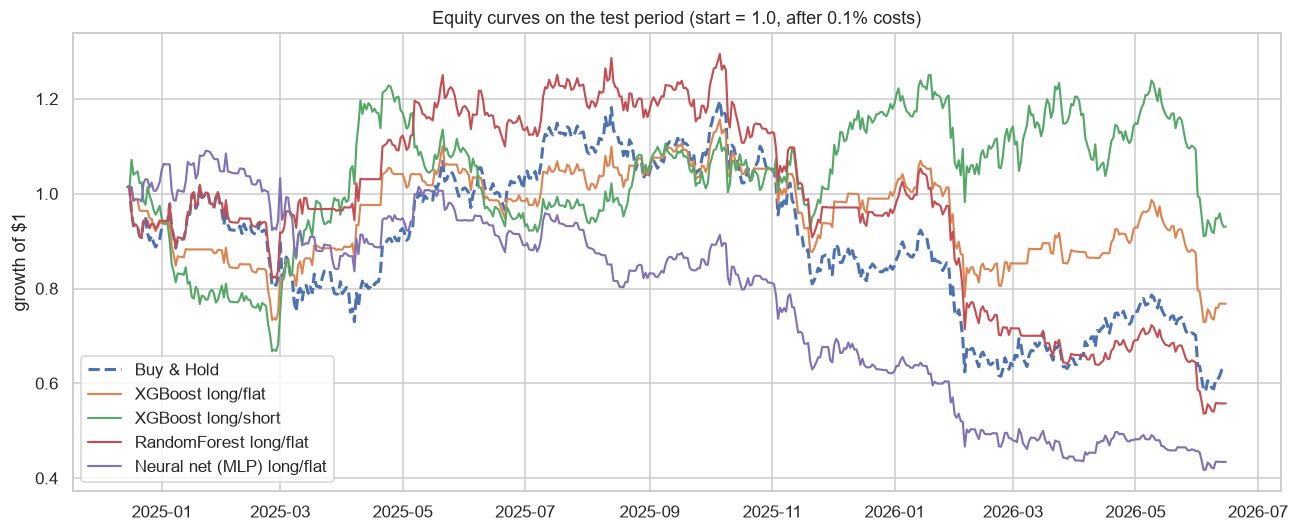

In [4]:
fig,ax=plt.subplots(figsize=(12,5))
for name,eq in curves.items():
    s="--" if name=="Buy & Hold" else "-"; lw=2 if name=="Buy & Hold" else 1.4
    ax.plot(bt["date"],eq,s,lw=lw,label=name)
ax.set_title("Equity curves on the test period (start = 1.0, after 0.1% costs)")
ax.set_ylabel("growth of $1"); ax.legend()
fig.tight_layout(); fig.savefig(FIG/"equity_curves.png",bbox_inches="tight"); plt.show()

## Honest read
The likely story is sobering: **long/short** variants churn constantly, so the 0.1% cost compounds into a serious drag. **long/flat** model strategies may or may not edge buy-and-hold, and rarely by enough to justify the complexity. The lesson recruiters respect: **accuracy is not profit.** A 51% classifier that trades daily loses to costs; the signal only matters if it's right on the *big* moves and trades rarely.